# Professional Data Analyst — Advanced Mini-Project 1
## Advanced Python Data Exploration & Automated Reporting

**Dataset:** Sample - Superstore 2019.xls  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

> **Business Scenario:** A multinational retail company wants an automated analytical solution to monitor sales, profitability, customer behavior, and operational performance.


## 1. Project Objectives

By the end of this project, you should be able to:

1. Load and understand a real-world Excel dataset.
2. Perform an advanced data-quality audit.
3. Clean and transform data using reusable functions.
4. Engineer meaningful business features.
5. Apply OOP concepts to an analytics workflow.
6. Perform descriptive, correlation, distribution, and trend analysis.
7. Build at least 8 business-focused visualizations.
8. Automate KPI summaries and exports.
9. Use exception handling and performance optimization.
10. Communicate findings as business insights.

### Main rule
**Do not code everything at once.** Complete one section, inspect the result, then move to the next.


# Project Setup


In [1]:
! pip install xlrd
# 1. Import pandas
import pandas as pd
# 2. Import numpy
import numpy as np
# 3. Import matplotlib.pyplot
import matplotlib.pyplot as plt
# 4. Import seaborn
import seaborn as sns
import os

# Create results folder
os.makedirs('results', exist_ok=True)


# Load the Dataset


In [2]:
# Load the Excel workbook.
sup=pd.read_excel(r'/content/Superstore.xls')
# Display the first 5 rows of each relevant DataFrame.
sup.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Initial Data Inspection


In [3]:
# 1. Check the dimensions
print(f"Rows: {sup.shape[0]:,}")
print(f"Columns: {sup.shape[1]}\n")
# 2. Check the column names
print(f"Columns:{sup.columns}\n")
# 3. Check the data types
print(f"Data types:\n{sup.dtypes}\n")
# 4. Check basic statistics
print(f"Basic statistics:\n{sup.describe()}\n")
print(f"Unique values:\n{sup.nunique()}\n")
print(f"Null values:\n{sup.isnull().sum()}\n")

Rows: 9,994
Columns: 21

Columns:Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Data types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code              float64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Dis

### Initial data issues found

- The dataset contains **9994 records and 21 columns**.
- The dataset includes `identifiers` + `dates` + `categorical` + `numerical variables`.
- We have **11** missing values in **Postal Code** Column.
- There are remarkably high values in the sales column, and they need to be checked.
- There are negative values in **profit**, and they need to be checked to make sure they are correct.
- We have variance with the number of **orders** and count of **rows**.
- We found a **high percentage of discounts**, and we need to understand how this **affects our revenue**.

# Build a Data Dictionary


In [4]:
# a small data dictionary for the most important columns.

data_dictionary = pd.DataFrame({"column_name": ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode','Customer ID', 'Segment','Region', 'Product ID', 'Category','Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount','Profit'],
                                "data_type": ['categorical', 'date', 'date', 'categorical', 'categorical', 'categorical', 'categorical', 'categorical', 'categorical', 'categorical', 'categorical', 'numeric', 'numeric', 'numeric', 'numeric'],
                               "Business Meaning":['Unique identifier for an order','Date when the order was placed','Date when the order was shipped','Shipping method selected for the order','Unique identifier for each customer','Customer segment associated with the order','Geographic region associated with the order','Unique identifier for each product','Main category of the product','More specific product classification within a category','Name of the product purchased','Revenue generated from the order line','Number of units purchased in the order line','Discount percentage applied to the order line','Profit or loss generated from the order line'],
                                "Analytical Role":['Identifier / Order-level Analysis','Date / Time Series Analysis','Date / Operational Analysis','Categorical / Grouping','Identifier / Customer Analysis','Categorical / Grouping','Categorical / Geographic Analysis','Identifier / Product Analysis','Categorical / Grouping','Categorical / Grouping','Categorical / Product Analysis','Numerical / KPI / Aggregation','Numerical / KPI / Aggregation','Numerical / Correlation Analysis','Numerical / KPI / Profitability Analysis']})
data_dictionary



,column_name,data_type,Business Meaning,Analytical Role
0,Order ID,categorical,Unique identifier for an order,Identifier / Order-level Analysis
1,Order Date,date,Date when the order was placed,Date / Time Series Analysis
2,Ship Date,date,Date when the order was shipped,Date / Operational Analysis
3,Ship Mode,categorical,Shipping method selected for the order,Categorical / Grouping
4,Customer ID,categorical,Unique identifier for each customer,Identifier / Customer Analysis
5,Segment,categorical,Customer segment associated with the order,Categorical / Grouping
6,Region,categorical,Geographic region associated with the order,Categorical / Geographic Analysis
7,Product ID,categorical,Unique identifier for each product,Identifier / Product Analysis
8,Category,categorical,Main category of the product,Categorical / Grouping
9,Sub-Category,categorical,More specific product classification within a ...,Categorical / Grouping


The data dictionary classifies the main variables into identifiers, date fields, categorical variables, and numerical measures. Numerical variables such as Sales, Quantity, Discount, and Profit will be used for KPI and statistical analysis, while categorical variables such as Category, Region, and Segment will be used for grouping and comparison. Date fields will support time-based analysis.

# Advanced Data Quality Audit


In [5]:
# Missing-value summary
print (f"Null values:\n{sup.isnull().sum()}\n")
# Duplicate summary
print (f"Duplicate values:\n{sup.duplicated().sum()}\n")
# Unique values for important categorical columns
print (f'Uniqe values:\n{sup.nunique()}\n')
categorical_columns = [
    'Ship Mode',
    'Segment',
    'Region',
    'Category',
    'Sub-Category'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(sup[col].value_counts())

Null values:
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

Duplicate values:
0

Uniqe values:
Row ID            9994
Order ID          5009
Order Date        1236
Ship Date         1334
Ship Mode            4
Customer ID        793
Customer Name      793
Segment              3
Country/Region       1
City               531
State               49
Postal Code        630
Region               4
Product ID        1862
Category             3
Sub-Category        17
Product Name      1850
Sales             6144
Quantity            14
Discount            12
Profit            7545
dtype: int64



## Categorical Data Quality Audit

The main categorical variables were examined using unique values and frequency distributions.

The analysis covered Ship Mode, Segment, Region, Category, and Sub-Category.

No obvious spelling inconsistencies, unexpected categories, or formatting issues were identified in these variables.

The categorical data appears consistent and suitable for further analysis.

In [6]:
# D. Date validity checks
sup['Shipping Duration']= (sup['Ship Date'] - sup['Order Date']).dt.days
print(f"Shipping Before Order :({(sup['Shipping Duration'] < 0).sum()})\n")
print(f"Shipping Before Order by Valiue:{sup.loc[sup['Shipping Duration'] < 0,['Order ID', 'Order Date', 'Ship Date', 'Shipping Duration']]}\n")
print(f"Shipping in the same Requested day :({(sup['Shipping Duration'] == 0).sum()})\n")

Shipping Before Order :(0)

Shipping Before Order by Valiue:Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Shipping Duration]
Index: []

Shipping in the same Requested day :(519)



## Date Validation

The relationship between Order Date and Ship Date was validated by calculating the Shipping Duration in days.

No records were found where the shipping date occurred before the order date, confirming that the date relationship is logically consistent.

There were 519 records with a Shipping Duration of zero days, indicating that the order was shipped on the same day it was placed. This is considered valid and is consistent with the Same Day shipping option.

In [7]:
# E. Numeric range checks
print (f'Quantity Of Orders lees then "0": ({(sup["Quantity"] < 0).sum()})\n')
print (f"Quantity Of Orders by Valiue: {sup.loc[sup['Quantity'] <= 0,['Order ID', 'Product ID', 'Quantity']]}\n")
print (f'Sales Of Orders lees then "0": ({(sup["Sales"] < 0).sum()})\n')
print (f"Negative Discount:({(sup['Discount'] < 0).sum()})\n")
print (f"Discount Above 100%:({(sup['Discount'] > 1).sum()})\n")

Quantity Of Orders lees then "0": (0)

Quantity Of Orders by Valiue: Empty DataFrame
Columns: [Order ID, Product ID, Quantity]
Index: []

Sales Of Orders lees then "0": (0)

Negative Discount:(0)

Discount Above 100%:(0)



## Numerical Data Validation

The main numerical variables were checked for invalid or logically impossible values.

The Quantity column contains no zero or negative values, and the Sales column contains no negative values.

The Discount column was also validated to ensure that all values are between 0 and 1. No negative discounts or discounts above 100% were identified.

Overall, the numerical fields passed the initial validity checks and are suitable for further analysis.

# Document Cleaning Decisions


In [8]:
# Create a cleaning decision table or dictionary.
sup[sup['Postal Code'].isna()][['Order ID', 'Customer Name', 'City', 'State', 'Region', 'Postal Code']]
sup[(sup['City'] == 'Burlington') & (sup['State'] == 'Vermont')][['City','State','Postal Code']].value_counts(dropna=False)
sup['Postal Code'] = sup['Postal Code'].astype('string')
sup['Postal Code'] = sup['Postal Code'].replace('<NA>', pd.NA)
print(sup['Postal Code'].dtype)
print("Missing Postal Codes:", sup['Postal Code'].isna().sum())
sup[sup['Postal Code'].isna()][['Order ID', 'City', 'State', 'Postal Code']]


string
Missing Postal Codes: 11


,Order ID,City,State,Postal Code
2234,CA-2019-104066,Burlington,Vermont,<NA>
5274,CA-2017-162887,Burlington,Vermont,<NA>
8798,US-2018-150140,Burlington,Vermont,<NA>
9146,US-2018-165505,Burlington,Vermont,<NA>
9147,US-2018-165505,Burlington,Vermont,<NA>
9148,US-2018-165505,Burlington,Vermont,<NA>
9386,US-2019-127292,Burlington,Vermont,<NA>
9387,US-2019-127292,Burlington,Vermont,<NA>
9388,US-2019-127292,Burlington,Vermont,<NA>
9389,US-2019-127292,Burlington,Vermont,<NA>


## Missing Value Treatment — Postal Code

The Postal Code column contains 11 missing values.

All missing records belong to Burlington, Vermont. No valid Postal Code for this City and State combination was available within the dataset, so the missing values could not be reliably inferred.

The records were retained, and the missing Postal Code values were preserved as genuine missing values. Since Postal Code is a geographic identifier, it was treated as a string rather than a numerical measure.

No artificial values were introduced.

In [9]:
Region = sup.groupby("Region", as_index=False).agg(Sales=("Sales","sum"),
                     Profit=("Profit","sum")).sort_values("Sales", ascending=False)
Region

,Region,Sales,Profit
3,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
0,Central,501239.8908,39706.3625
2,South,391721.9050,46749.4303


### Missing Values Checking Function

#### Why?

Missing values are an important part of data cleaning. Instead of manually checking each column, we can create one function that performs the check automatically.

In [10]:
def check_missing_values(sup):
    """
    Check the number of missing values in each column of a DataFrame.
    """
    missing_values = sup.isnull().sum()
    return missing_values

check_missing_values(sup)

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


### Duplicate Records Checking Function

#### Business Purpose

Duplicate records can affect KPIs and statistical analysis by counting the same transaction more than once.

Therefore, duplicate records should be checked before performing analytical calculations.

In [11]:
def check_duplicates(sup):
    """
    Check the number of duplicate rows in the dataset.
    """
    duplicate_count = sup.duplicated().sum()

    return duplicate_count

print(f"Total of duplicates : {check_duplicates(sup)}")

Total of duplicates : 0


## Outlier Detection Function

### Business Purpose
This analysis helps identify unusual sales, profit, quantity, or discount values that may require further investigation.


#### Why?

Outliers can significantly affect averages, distributions, correlations, and statistical analysis.

The function should calculate:

- Q1
- Q3
- IQR
- Lower Bound
- Upper Bound
- Number of Outliers
- Outlier Percentage

In [12]:
def detect_outliers(sup, columns):
    """
    Detect outliers in a numerical column using the IQR method.
    """

    results= []

    for column in columns:

      Q1 = sup[column].quantile(0.25)
      Q3 = sup[column].quantile(0.75)
      IQR = Q3 - Q1
      Lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR

      outliers = (sup[column] < Lower_bound) | (sup[column] > upper_bound)

      number_of_outliers= outliers.sum()
      outlier_percentage = (number_of_outliers / len(sup)) * 100

      results.append({
                "Column" : column,
                "Q1" : Q1,
                "Q3" :Q3 ,
                "IQR" : IQR ,
                "Lower Bound" : Lower_bound ,
                "Upper Bound" : upper_bound ,
                "Number of Outliers" : number_of_outliers,
                "outlier_percentage"  : outlier_percentage

      })
    return pd.DataFrame(results)

detect_outliers ( sup, ['Sales', 'Profit', 'Quantity', 'Discount'])

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,outlier_percentage
0,Sales,17.28000,209.940,192.66000,-271.710000,498.930000,1167,11.677006
1,Profit,1.72875,29.364,27.63525,-39.724125,70.816875,1881,18.821293
2,Quantity,2.00000,5.000,3.00000,-2.500000,9.500000,170,1.701021
3,Discount,0.00000,0.200,0.20000,-0.300000,0.500000,856,8.565139


# Outlier Analysis


In [13]:
Q1 = sup['Sales'].quantile(0.25)
Q3 = sup['Sales'].quantile(0.75)
IQR = Q3 - Q1

Lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1" , Q1)
print("Q3" , Q3)
print("IQR" , IQR)
print(f"Lower_bound: {Lower_bound :.2f}")
print(f"upper_bound: {upper_bound :.2f}")

sales_outliers = sup[(sup['Sales']< Lower_bound) | (sup['Sales'] > upper_bound)]
print(f"Number of Sales Outliers:", len(sales_outliers))
outlier_percentage = (len(sales_outliers) / len(sup)) * 100
print (f"Outlier Percentage: {outlier_percentage : .2f}%\n")
sales_outliers[['Order ID', 'Product ID', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']].head(10)

Q1 17.28
Q3 209.94
IQR 192.66
Lower_bound: -271.71
upper_bound: 498.93
Number of Sales Outliers: 1167
Outlier Percentage:  11.68%



,Order ID,Product ID,Product Name,Sales,Quantity,Discount,Profit
1,CA-2018-152156,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,US-2017-108966,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,CA-2016-115812,TEC-PH-10002275,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,CA-2016-115812,FUR-TA-10001539,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
11,CA-2016-115812,TEC-PH-10002033,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568
16,CA-2016-105893,OFF-ST-10004186,"Stur-D-Stor Shelving, Vertical 5-Shelf: 72""H x...",665.8800,6,0.00,13.3176
24,CA-2017-106320,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
27,US-2017-150630,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
35,CA-2018-117590,TEC-PH-10004977,GE 30524EE4,1097.5440,7,0.20,123.4737
38,CA-2017-117415,FUR-BO-10002545,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",532.3992,3,0.32,-46.9764


## Sales Outlier Analysis

The IQR method identified 1,167 potential outliers in the Sales variable, representing approximately 11.68% of the dataset.

The upper bound was calculated as 498.93, meaning that sales values above this threshold were flagged as potential outliers.

Further inspection showed that these records represent legitimate transactions with relatively high sales values. Some records also contain high discounts and negative profits, which may indicate business performance issues rather than data quality errors.

Therefore, the identified sales outliers will not be removed at this stage. They will be retained for further business and profitability analysis.

In [14]:
Q1_profit = sup['Profit'].quantile(0.25)
Q3_profit = sup['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

Lower_bound_proft = Q1_profit - 1.5 * IQR_profit
upper_bound_profit = Q3_profit + 1.5 * IQR_profit

print(f"Q1_Profit:{Q1_profit: .2f}")
print(f"Q3_Profit :{Q3_profit: .2f}")
print(f"IQR_Profit:{IQR_profit : .2f}")
print(f"Lower_bound_Profit:{Lower_bound_proft : .2f}")
print(f"upper_bound_Profit:{upper_bound_profit : .2f}\n")

profit_outliers = sup[(sup['Profit'] < Lower_bound_proft) | (sup['Profit'] > upper_bound_profit)]
print(f"Number of Profit Outliers:", len(profit_outliers))
profit_outlier_percentage = (len(profit_outliers) / len(sup)) * 100
print (f"Profit Outlier Percentage: {profit_outlier_percentage : .2f}%\n")
profit_outliers[['Order ID', 'Product ID', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']].head(10)

Q1_Profit: 1.73
Q3_Profit : 29.36
IQR_Profit: 27.64
Lower_bound_Profit:-39.72
upper_bound_Profit: 70.82

Number of Profit Outliers: 1881
Profit Outlier Percentage:  18.82%



,Order ID,Product ID,Product Name,Sales,Quantity,Discount,Profit
1,CA-2018-152156,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,US-2017-108966,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,CA-2016-115812,TEC-PH-10002275,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,CA-2016-115812,FUR-TA-10001539,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
13,CA-2018-161389,OFF-BI-10003656,Fellowes PB200 Plastic Comb Binding Machine,407.9760,3,0.20,132.5922
14,US-2017-118983,OFF-AP-10002311,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
24,CA-2017-106320,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
27,US-2017-150630,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
35,CA-2018-117590,TEC-PH-10004977,GE 30524EE4,1097.5440,7,0.20,123.4737
36,CA-2018-117590,FUR-FU-10003664,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


## Profit Outlier Analysis

The IQR method was applied to the Profit variable to identify potential outliers.

The calculated lower and upper bounds were -39.72 and 70.82 respectively.

A total of 1,881 records, representing approximately 18.82% of the dataset, were identified as potential profit outliers.

Inspection of sample records showed that these values include both unusually high profits and significant losses. The negative profit values are not considered data quality errors because they can represent legitimate business losses.

Therefore, the identified profit outliers will be retained for further business analysis, particularly to investigate the relationship between discount, sales, and profitability.

## Outlier Investigation

### Objective

Investigate whether statistical outliers represent data quality issues
or legitimate business transactions.

### Business Question

Do high discount levels contribute to negative profitability?

### Approach

We will compare Discount and Profit values to identify unusual
business patterns and investigate whether high discounts are associated
with financial losses.

### Important Note

Outliers will not be removed automatically.

A statistical outlier may represent a legitimate business transaction,
so further analysis is required before making any data-cleaning decision.

In [15]:
discount_profit_analysis = sup[
    ['Discount','Profit','Sales']
   ].sort_values(by='Discount', ascending=False)
discount_profit_analysis.head(20)

sup.groupby("Discount")['Profit'].agg(
    ["count","mean","sum"]
).sort_index()

discount_profit= sup.groupby("Discount")["Profit"].mean()
discount_profit.head(20)

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


### Business Insight

The analysis shows a clear negative relationship between discount levels
and average profit.

Average profit remains positive at discount levels up to 20%.
However, average profit becomes negative starting at a 30% discount.

The 50% discount level has the lowest average profit, at approximately
-310.70.

This suggests that high discount levels may negatively affect profitability
and should be investigated further.

> Note: This analysis identifies an association, not a causal relationship.

## Visualization: Average Profit by Discount Level

### Objective

Visualize how average profit changes across different discount levels.

### Business Question

How does average profitability change as the discount level increases?

### Expected Insight

The visualization should make it easier to identify discount levels
associated with positive and negative profitability.

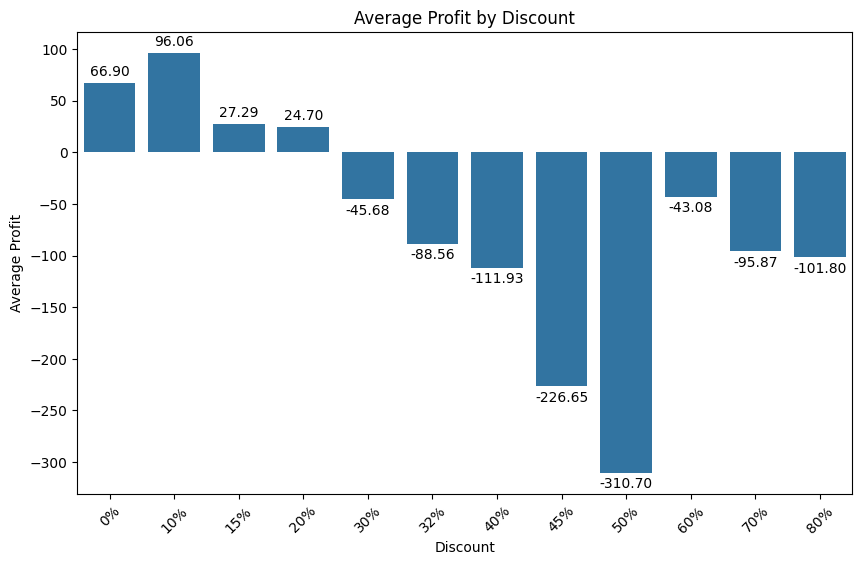

In [16]:

from matplotlib.ticker import PercentFormatter
plt.figure(figsize=(10,6))

ax=sns.barplot(
x = discount_profit.index,
y = discount_profit.values
)


#     x,
#     y,
#     width=0.018
# )

plt.bar_label(ax.containers[0],fmt="%.2f",padding=3)

ax.xaxis.set_major_formatter(PercentFormatter(1))
# Convert Discount labels to percentages
# ax.xaxis.set_major_formatter(PercentFormatter(1))

# Get current tick positions
ax.set_xticks(range(len(discount_profit.index)))

# Convert Discount values to percentages
#     [f'{x:.0%}' for x in discount_profit.index]
# )

ax.set_xticklabels(
    [f'{x:.0%}' for x in discount_profit.index]
)

ax.set_title('Average Profit by Discount')
ax.set_xlabel('Discount')
ax.set_ylabel('Average Profit')

plt.xticks(rotation=45)
plt.savefig('results/Visualization_1.png')
plt.show()


## Feature Engineering — Profit Margin

Profit Margin measures the percentage of sales revenue that remains as profit.

It is calculated as:

Profit Margin = (Profit / Sales) × 100

This feature will help evaluate profitability independently of the sales volume.

In [17]:
# Create Profit Margin.
sup['Profit Margin'] = (sup['Profit'] / sup['Sales'] * 100)
sup[['Sales', 'Profit', 'Profit Margin']].head(10)

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25
5,48.8600,14.1694,29.00
6,7.2800,1.9656,27.00
7,907.1520,90.7152,10.00
8,18.5040,5.7825,31.25
9,114.9000,34.4700,30.00


### Profit Margin Interpretation

The Profit Margin feature represents profitability relative to sales.

Positive values indicate profitable transactions, while negative values indicate loss-making transactions.

For example, a transaction with Sales of 957.58 and Profit of -383.03 has a Profit Margin of approximately -40%, indicating a significant loss relative to the sales value.

This feature will be useful for comparing profitability across products, categories, customers, and regions.

## Feature Engineering — Shipping Duration

Shipping Duration represents the number of days between the Order Date and Ship Date.

It is calculated by subtracting Order Date from Ship Date.

This feature will be used to analyze shipping performance and compare delivery duration across shipping modes, regions, and customer segments.

In [18]:
# Validate Shipping Duration and inspect the generated date features.
print(sup[['Order Date', 'Ship Date','Shipping Duration']].head(10),"\n")
print(sup['Shipping Duration'].describe(),"\n")
print (f"Negative Shipping Duration:{(sup['Shipping Duration'] < 0).sum()}\n")
print (f"Shipping Duration Frequency: {sup['Shipping Duration'].value_counts().sort_index()}")

  Order Date  Ship Date  Shipping Duration
0 2018-11-08 2018-11-11                  3
1 2018-11-08 2018-11-11                  3
2 2018-06-12 2018-06-16                  4
3 2017-10-11 2017-10-18                  7
4 2017-10-11 2017-10-18                  7
5 2016-06-09 2016-06-14                  5
6 2016-06-09 2016-06-14                  5
7 2016-06-09 2016-06-14                  5
8 2016-06-09 2016-06-14                  5
9 2016-06-09 2016-06-14                  5 

count    9994.000000
mean        3.958075
std         1.747937
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Duration, dtype: float64 

Negative Shipping Duration:0

Shipping Duration Frequency: Shipping Duration
0     519
1     369
2    1336
3    1004
4    2772
5    2170
6    1202
7     622
Name: count, dtype: int64


### Shipping Duration Analysis

The Shipping Duration feature was created by calculating the number of days between Order Date and Ship Date.

The analysis shows that:

- The average shipping duration is approximately 3.96 days.
- The minimum shipping duration is 0 days.
- The maximum shipping duration is 7 days.
- No negative shipping durations were detected.
- The most common shipping duration is 4 days, with 2,772 orders.
- 519 orders were shipped on the same day.

The shipping duration distribution indicates that most orders are shipped within 4–5 days.

In [19]:
# Verify the new columns with sample rows and summary statistics.
sup['Order Year'] = sup ['Order Date'].dt.year
sup['Order Month']= sup['Order Date'].dt.month
sup['Order Quarter']= sup['Order Date'].dt.quarter
sup['Order Day']= sup['Order Date'].dt.day
sup['Order Day of Week']= sup['Order Date'].dt.day_of_week

sup[['Order Year', 'Order Month', 'Order Quarter', 'Order Day', 'Order Day of Week']].describe()

,Order Year,Order Month,Order Quarter,Order Day,Order Day of Week
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2017.722233,7.809686,2.882329,15.468381,2.712528
std,1.123555,3.284654,1.058086,8.748178,2.063611
min,2016.000000,1.000000,1.000000,1.000000,0.000000
25%,2017.000000,5.000000,2.000000,8.000000,1.000000
50%,2018.000000,9.000000,3.000000,15.000000,2.000000
75%,2019.000000,11.000000,4.000000,23.000000,5.000000
max,2019.000000,12.000000,4.000000,31.000000,6.000000


### Date Feature Validation Results

The date features were successfully created and validated.

- The dataset contains orders from **2016 to 2019**.
- `Order Month` ranges from **1 to 12**.
- `Order Quarter` ranges from **1 to 4**.
- `Order Day` ranges from **1 to 31**.
- `Order Day of Week` ranges from **0 to 6**.

No unexpected ranges were observed in the generated date features.

These features are now ready to be used in the upcoming **time-series and trend analysis**.

## Feature Engineering — Sales Performance Category

Sales transactions are classified into four performance categories based on the quartiles of the Sales distribution.

The categories are:

- Low: Sales <= Q1
- Medium: Q1 < Sales <= Q2
- High: Q2 < Sales <= Q3
- Very High: Sales > Q3

Using data-driven thresholds makes the classification relative to the actual distribution of sales.

In [20]:
# Create Sales Performance Category.
sales_Q1 = sup['Sales'].quantile(0.25)
sales_Q2 = sup['Sales'].quantile(0.50)
sales_Q3 = sup['Sales'].quantile(0.75)

print("Sales Q1:", sales_Q1)
print("Sales Q2:", sales_Q2)
print("Sales Q3:", sales_Q3)

sup['Sales Performance Category']=pd.cut(sup['Sales'], bins=[-float('inf'),sales_Q1,sales_Q2,sales_Q3,float('inf')],
                                         labels=['Low', 'Medium', 'High', 'Very High'],include_lowest=True)
print("\n",sup[['Sales', 'Sales Performance Category']].head(10),"\n")
print(sup['Sales Performance Category'].value_counts().reset_index(),"\n")
print(f"Sales Performance Category missing: {sup['Sales Performance Category'].isna().sum()}")

Sales Q1: 17.28
Sales Q2: 54.489999999999995
Sales Q3: 209.94

       Sales Sales Performance Category
0  261.9600                  Very High
1  731.9400                  Very High
2   14.6200                        Low
3  957.5775                  Very High
4   22.3680                     Medium
5   48.8600                     Medium
6    7.2800                        Low
7  907.1520                  Very High
8   18.5040                     Medium
9  114.9000                       High 

  Sales Performance Category  count
0                        Low   2501
1                       High   2499
2                  Very High   2498
3                     Medium   2496 

Sales Performance Category missing: 0


### Sales Performance Category Results

The Sales variable was divided into four data-driven performance categories using its quartiles.

The resulting categories contain a similar number of records:

- Low: 2,501 records
- Medium: 2,496 records
- High: 2,499 records
- Very High: 2,498 records

No records were assigned a missing category.

The balanced distribution is expected because quartile-based thresholds divide the dataset into approximately four equal groups.

# Object-Oriented Programming


In [21]:
# Object-Oriented Programming

class SuperstoreAnalyzer:

    # Constructor
    def __init__(self, sup):
        self.sup = sup

    # Calculate Total Sales
    def total_sales(self):
        return self.sup['Sales'].sum()

    # Calculate Total Profit
    def total_profit(self):
        return self.sup['Profit'].sum()

    # Calculate Profit Margin
    def profit_margin(self):
        sales = self.total_sales()
        profit = self.total_profit()

        return (profit / sales) * 100

      # Create an object

analyzer = SuperstoreAnalyzer(sup)
# Display results

print(f"Total Sales: { analyzer.total_sales():0.0f}")
print(f"Total Profit: { analyzer.total_profit():0.0f}")
print(f"Profit Margin: { analyzer.profit_margin():0.0f}""%")

Total Sales: 2297201
Total Profit: 286397
Profit Margin: 12%


# KPI Analysis


In [22]:
def calculate_kpis(sup):
    """
    Calculate the main business KPIs for the Superstore dataset.
    """

    # 1. Total Sales
    total_sales = sup['Sales'].sum()

    # 2. Total Profit
    total_profit = sup['Profit'].sum()

    # 3. Overall Profit Margin
    overall_profit_margin = (
        total_profit / total_sales
    ) * 100

    # 4. Total Orders
    total_orders = sup['Order ID'].nunique()

    # 5. Unique Customers
    unique_customers = sup['Customer ID'].nunique()

    # 6. Unique Products
    unique_products = sup['Product ID'].nunique()

    # 7. Total Quantity
    total_quantity = sup['Quantity'].sum()

    # 8. Average Order Value
    average_order_value = (
        total_sales / total_orders
    )

    # 9. Average Shipping Duration
    average_shipping_duration = (
        sup['Shipping Duration'].mean()
    )

    # Create KPI summary
    kpi_summary = pd.DataFrame({
        'KPI': [
            'Total Sales',
            'Total Profit',
            'Overall Profit Margin',
            'Total Orders',
            'Unique Customers',
            'Unique Products',
            'Total Quantity',
            'Average Order Value',
            'Average Shipping Duration'
        ],
        'Value': [
            total_sales,
            total_profit,
            overall_profit_margin,
            total_orders,
            unique_customers,
            unique_products,
            total_quantity,
            average_order_value,
            average_shipping_duration
        ]
    })

    return kpi_summary


# Calculate KPIs
kpi_summary = calculate_kpis(sup)


# Create a copy for professional display
kpi_display = kpi_summary.copy()


# KPIs that should be displayed as whole numbers
integer_kpis = [
    'Total Orders',
    'Unique Customers',
    'Unique Products',
    'Total Quantity'
]


# Format the KPI values
kpi_display['Value'] = kpi_display.apply(
    lambda row: (
        f"{row['Value']:,.0f}"
        if row['KPI'] in integer_kpis
        else f"{row['Value']:,.2f}"
    ),
    axis=1
)


# Display the final KPI summary
kpi_display

,KPI,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Overall Profit Margin,12.47
3,Total Orders,"5,009"
4,Unique Customers,793
5,Unique Products,"1,862"
6,Total Quantity,"37,873"
7,Average Order Value,458.61
8,Average Shipping Duration,3.96


# Descriptive EDA

### Business thinking
Do not stop at "X is highest." Ask:
- Why might it be highest?
- Is high sales accompanied by high profit?
- Where are the weak areas?


In [23]:
category_performance = sup.groupby("Category")[['Sales','Profit']].sum()
category_performance

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


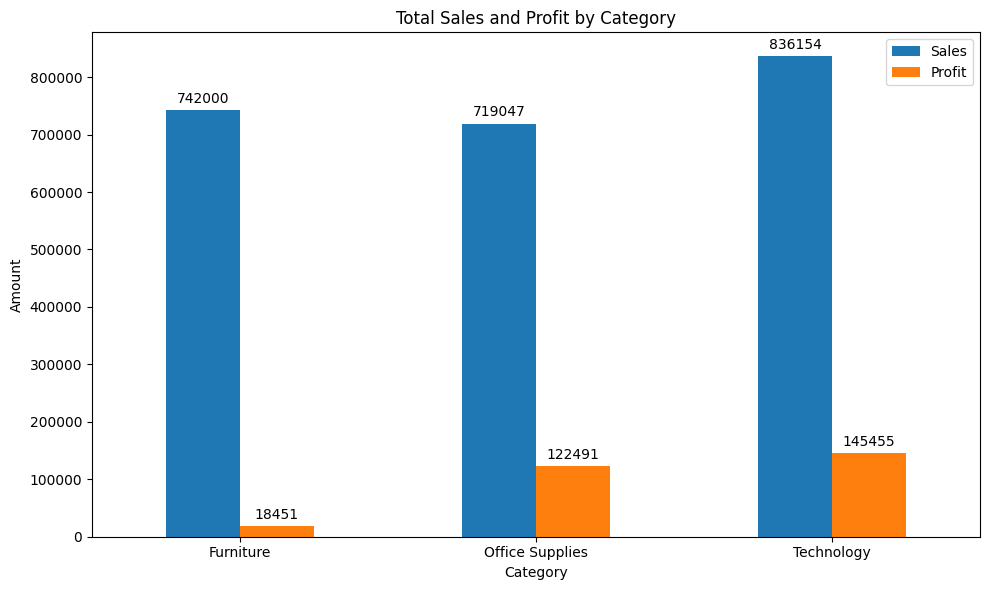

In [24]:
#  Visualization  — Sales & Profit by Category
ax = category_performance.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Total Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')

plt.xticks(rotation=0)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.savefig('results/Visualization_2.png')
plt.show()

### Category Performance Analysis

This analysis compares the total Sales and Profit across different Product Categories.

The objective is to identify which categories generate the highest revenue and which categories contribute the most to overall profitability.

#### Key Business Questions:
- Which category generates the highest Sales?
- Which category generates the highest Profit?
- Is the category with the highest Sales also the most profitable?

#### Business Insight:
Comparing Sales and Profit helps identify whether high revenue is also associated with strong profitability.

In [25]:
category_performance['Profit Margin'] =( category_performance['Profit'] / category_performance ['Sales']) *100
category_performance

,Sales,Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


### Profit Margin by Category

Profit Margin is used to compare the profitability of each product category relative to its sales.

#### Key Insights:

- Technology has the highest Profit Margin at approximately 17.40%.
- Office Supplies has a similar Profit Margin of approximately 17.04%.
- Furniture has a significantly lower Profit Margin of approximately 2.49%.
- Although Furniture generates high Sales, its profitability is much lower than the other categories.

#### Business Insight:

Furniture requires further investigation because its high Sales are not translating into strong profitability.
The next analysis will investigate Sub-Categories and Discount levels to identify possible reasons for the low profitability.

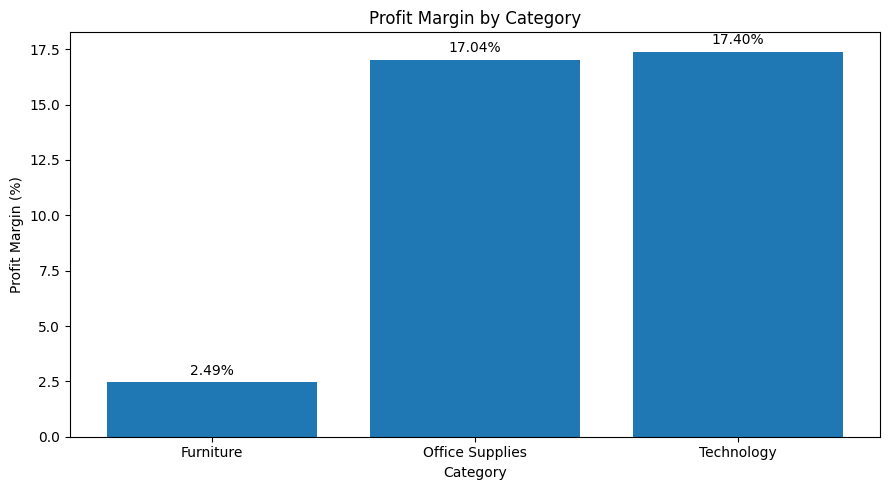

In [26]:
#  Visualization  — Profit Margin by Category

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    category_performance.index,
    category_performance['Profit Margin']
)

ax.set_title('Profit Margin by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Profit Margin (%)')

ax.bar_label(
    bars,
    fmt='%.2f%%',
    padding=3
)
plt.tight_layout()
plt.savefig('results/Visualization_3.png')
plt.show()

In [27]:
# Sales & Profit by Sub_Category
subcategory_performance = sup.groupby('Sub-Category')[['Sales','Profit']].sum()
subcategory_performance = subcategory_performance.sort_values('Profit',ascending=False)
subcategory_performance


,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


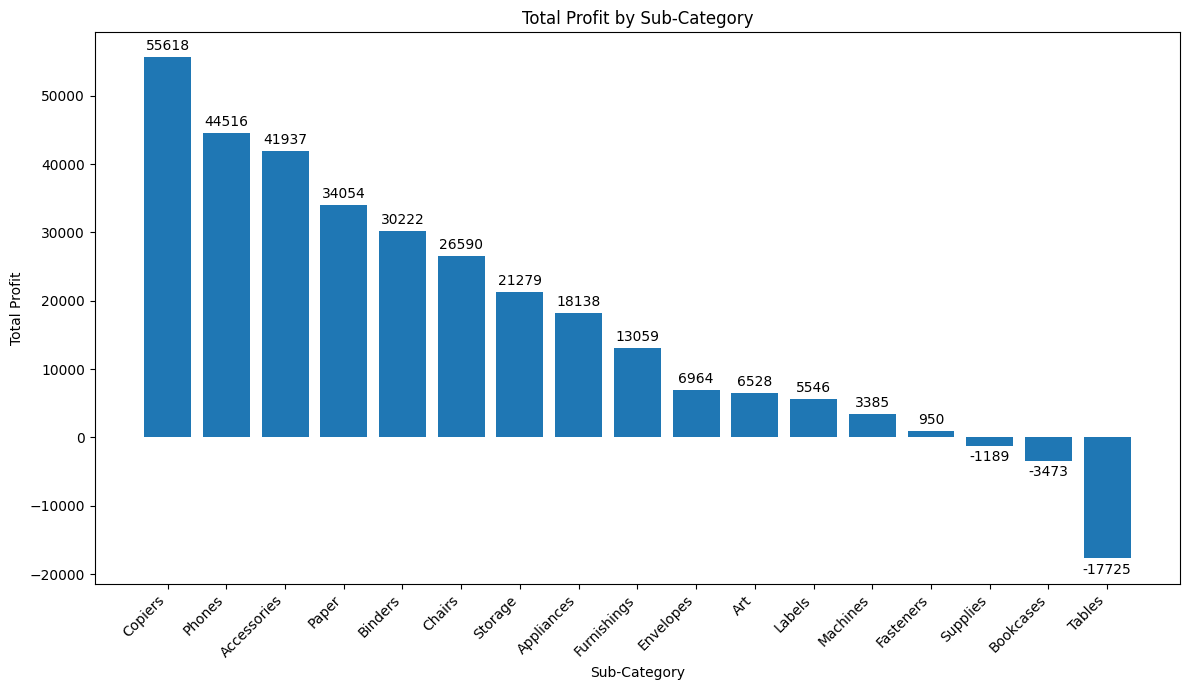

In [28]:
#  Visualization  —  Profit by Sub_Category

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    subcategory_performance.index,
    subcategory_performance['Profit']
)

ax.set_title('Total Profit by Sub-Category')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Total Profit')

ax.bar_label(
    bars,
    fmt='%.0f',
    padding=3
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/Visualization_4.png')
plt.show()

## Regional Performance Analysis

### Business Question
Which region generates the highest Sales, Profit, and Profit Margin?


In [29]:
# Regional Performance
regional_performance = (
    sup.groupby('Region')[['Sales', 'Profit']]
    .sum()
)

regional_performance['Profit Margin'] = (
    regional_performance['Profit']
    / regional_performance['Sales']
) * 100

regional_performance

,Sales,Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


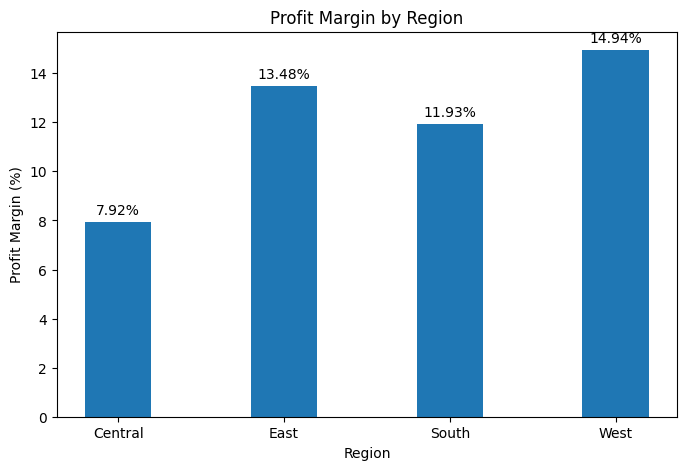

In [30]:
#  Visualization — Profit Margin by Region
plt.figure(figsize=(8, 5))

bars = plt.bar(
    regional_performance.index,
    regional_performance['Profit Margin'],width=0.4
)

plt.title('Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')

# Add values on top of bars
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.savefig('results/Visualization_5.png')
plt.show()

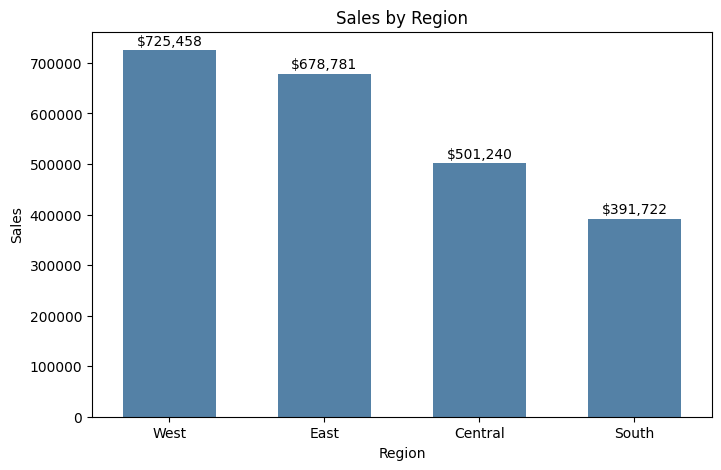

In [31]:
#  Visualization — Sales by Region
plt.figure(figsize=(8, 5))
# sns.barplot(data=Region, x="Region", y="Sales", color="steelblue")
ax = sns.barplot(
    data=Region,
    x="Region",
    y="Sales",
    color="steelblue",
    width=0.6
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

# Add sales values on top of bars
for i, value in enumerate(Region["Sales"]):
    ax.text(
        i,
        value + 10000,
        f"${value:,.0f}",
        ha="center"
    )
plt.savefig('results/Visualization_6.png')
plt.show()


# Correlation Analysis


In [32]:
# Correlation
correlation_columns = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'Profit Margin',
    'Shipping Duration'
]

correlation_data = sup[correlation_columns]
correlation_data.head()

,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
0,261.9600,2,0.00,41.9136,16.00,3
1,731.9400,3,0.00,219.5820,30.00,3
2,14.6200,2,0.00,6.8714,47.00,4
3,957.5775,5,0.45,-383.0310,-40.00,7
4,22.3680,2,0.20,2.5164,11.25,7


In [33]:
# Correlation Matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
Sales,1.000000,0.200795,-0.028190,0.479064,0.003444,-0.007350
Quantity,0.200795,1.000000,0.008623,0.066253,-0.005280,0.018315
Discount,-0.028190,0.008623,1.000000,-0.219487,-0.864452,0.000452
Profit,0.479064,0.066253,-0.219487,1.000000,0.223732,-0.004658
Profit Margin,0.003444,-0.005280,-0.864452,0.223732,1.000000,-0.011800
Shipping Duration,-0.007350,0.018315,0.000452,-0.004658,-0.011800,1.000000


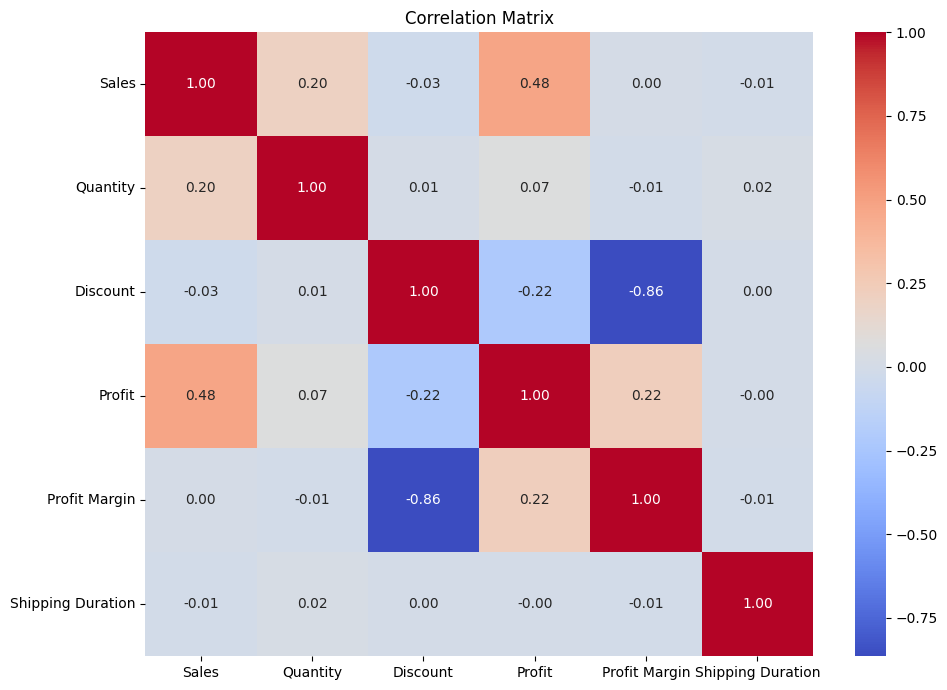

In [34]:
#  Correlation analysis
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.xticks(rotation=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('results/Visualization_7.png')
plt.show()

In [35]:
# Correlation Desaturate
strong_correlations = (
    correlation_matrix
    .where(~np.eye(correlation_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

strong_correlations

,,0
Discount,Profit Margin,-0.864452
Profit Margin,Discount,-0.864452
Profit,Sales,0.479064
Sales,Profit,0.479064
Profit,Profit Margin,0.223732
Profit Margin,Profit,0.223732
Discount,Profit,-0.219487
Profit,Discount,-0.219487
Quantity,Sales,0.200795
Sales,Quantity,0.200795


***Correlation Desaturate (Details)***:

---



| Relationship               | Correlation | Interpretation         |
| -------------------------- | ----------: | ---------------------- |
| Sales ↔ Profit             |   **+0.48** | Moderate positive      |
| Discount ↔ Profit          |   **-0.22** | Weak/Moderate negative |
| Discount ↔ Profit Margin   |   **-0.86** | Strong negative 🔥     |
| Profit ↔ Profit Margin     |   **+0.22** | Weak positive          |
| Sales ↔ Quantity           |   **+0.20** | Weak positive          |
| Shipping Duration ↔ Profit |  **-0.005** | Almost no relationship |

Discount has a strong negative relationship with Profit Margin (-0.86), suggesting that higher discounts are strongly associated with lower profitability efficiency.

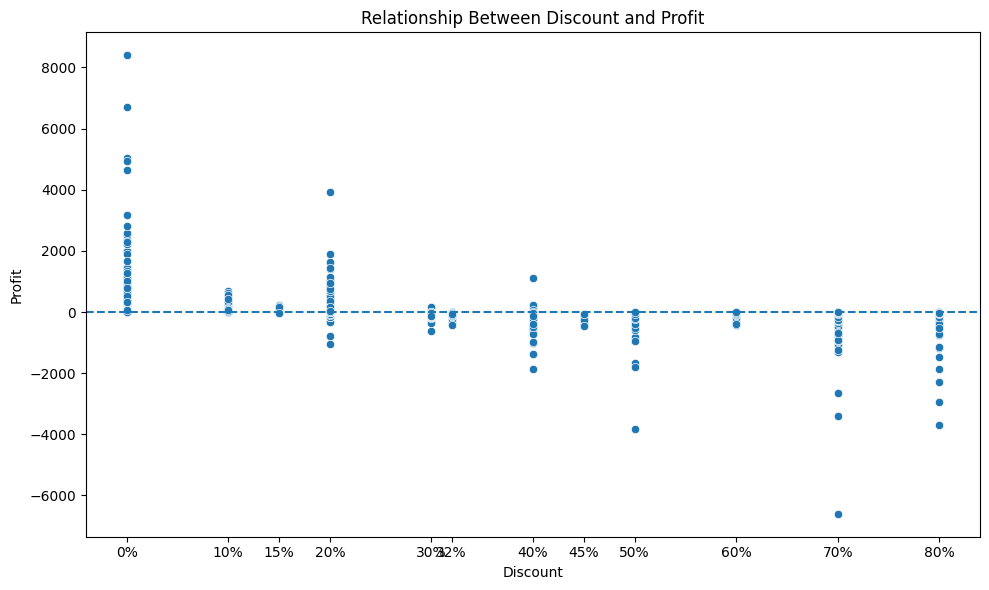

In [36]:
# Visualization  — Relationship Between Discount and Profit:

plt.figure(figsize=(10, 6))

ax=sns.scatterplot(
    data=sup,
    x='Discount',
    y='Profit'
)
# Format Discount values as percentages
ax.set_xticks(sorted(sup['Discount'].unique()))
ax.set_xticklabels(
    [f'{x:.0%}' for x in sorted(sup['Discount'].unique())]
)
plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.axhline(0, linestyle='--')
plt.tight_layout()
plt.savefig('results/Visualization_8.png')
plt.show()

Business Insight: Higher discount levels are generally associated with lower profitability. However, the relationship is not very strong at the overall transaction level, suggesting that other factors such as product category, sub-category, and sales value also influence profit.

## Monthly Sales and Profit Trend

### Business Question
How do Sales and Profit change across different months?


## Monthly & Yearly Performance Insights


In [37]:
# Monthly Performance for Sales & Profit

sup['Order Date'] = pd.to_datetime(sup['Order Date'])

sup['Month'] = sup['Order Date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_performance = (
    sup.groupby('Month')[['Sales', 'Profit']]
    .sum()
    .reindex(month_order)
)

monthly_performance

,Sales,Profit
Month,,
January,94924.8356,9134.4461
February,59751.2514,10294.6107
March,205005.4888,28594.6872
April,137762.1286,11587.4363
May,155028.8117,22411.3078
June,152718.6793,21285.7954
July,147238.0970,13832.6648
August,159044.0630,21776.9384
September,307649.9457,36857.4753


In [38]:
# Top Sales
monthly_performance.sort_values('Sales', ascending=False)

,Sales,Profit
Month,,
November,352461.0710,35468.4265
December,325293.5035,43369.1919
September,307649.9457,36857.4753
March,205005.4888,28594.6872
October,200322.9847,31784.0413
August,159044.0630,21776.9384
May,155028.8117,22411.3078
June,152718.6793,21285.7954
July,147238.0970,13832.6648


In [39]:
# Top Profit
monthly_performance.sort_values('Profit', ascending=False)

,Sales,Profit
Month,,
December,325293.5035,43369.1919
September,307649.9457,36857.4753
November,352461.0710,35468.4265
October,200322.9847,31784.0413
March,205005.4888,28594.6872
May,155028.8117,22411.3078
August,159044.0630,21776.9384
June,152718.6793,21285.7954
July,147238.0970,13832.6648


In [40]:
# Yearly Performance
yearly_performance = sup.groupby('Order Year')[['Sales', 'Profit']].sum()

yearly_performance

,Sales,Profit
Order Year,,
2016,484247.4981,49543.9741
2017,470532.5090,61618.6037
2018,609205.5980,81795.1743
2019,733215.2552,93439.2696


In [41]:
# Monthly & Yearly Performance Insights

best_month = monthly_performance['Sales'].idxmax()
best_month_sales = monthly_performance['Sales'].max()

best_year = yearly_performance['Sales'].idxmax()
best_year_sales = yearly_performance['Sales'].max()

print("========== PERFORMANCE INSIGHTS ==========")

print(
    f"Best month in terms of sales: "
    f"{best_month}, with sales of ${best_month_sales:,.2f}."
)

print(
    f"Best year in terms of sales: "
    f"{best_year}, with sales of ${best_year_sales:,.2f}."
)

========== PERFORMANCE INSIGHTS ==========
Best month in terms of sales: November, with sales of $352,461.07.
Best year in terms of sales: 2019, with sales of $733,215.26.


In [42]:
best_profit_month = monthly_performance['Profit'].idxmax()
best_profit_year = yearly_performance['Profit'].idxmax()

print(
    f"Most profitable month: "
    f"{best_profit_month}."
)

print(
    f"Most profitable year: "
    f"{best_profit_year}."
)

Most profitable month: December.
Most profitable year: 2019.


# Trend Analysis


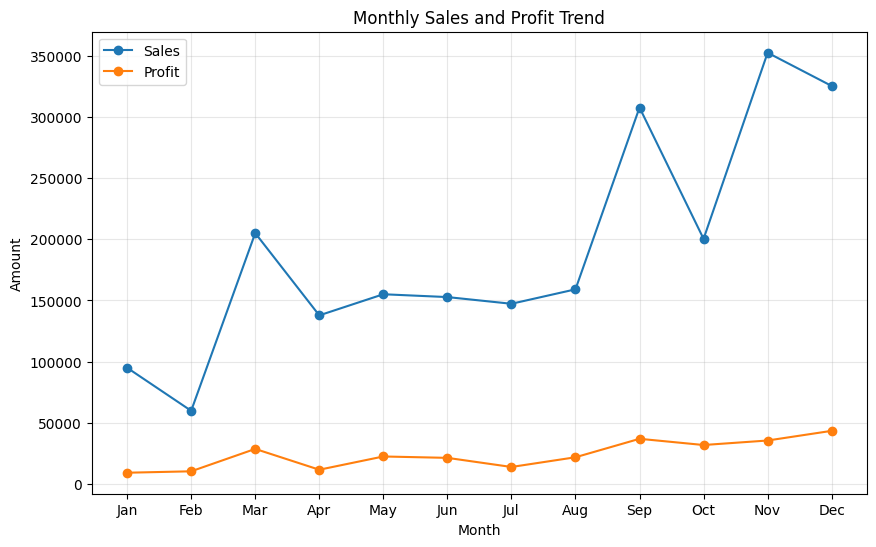

In [43]:
# Visualization — Monthly Sales & Profit Trend
import calendar
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance['Sales'],
    marker='o',
    label='Sales'
)

plt.plot(
    monthly_performance.index,
    monthly_performance['Profit'],
    marker='o',
    label='Profit'
)

plt.title('Monthly Sales and Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')

plt.xticks(
    range(12),
    [calendar.month_abbr[i] for i in range(1, 13)]
)

plt.legend()
plt.grid(alpha=0.3)
plt.savefig('results/Visualization_9.png')
plt.show()

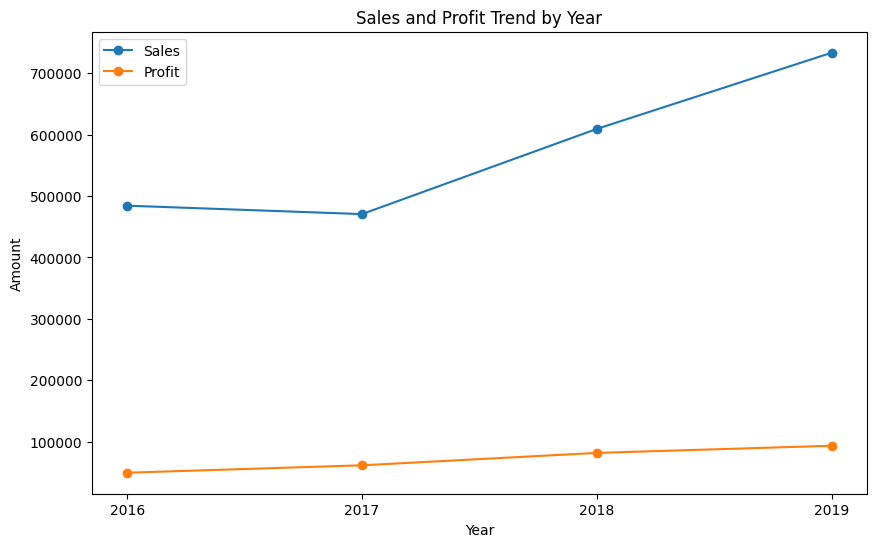

In [44]:
#Visualization - Yearly Sales & Profit Trend

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_performance.index,
    yearly_performance['Sales'],
    marker='o',
    label='Sales'
)

plt.plot(
    yearly_performance.index,
    yearly_performance['Profit'],
    marker='o',
    label='Profit'
)

plt.title('Sales and Profit Trend by Year')
plt.xlabel('Year')
plt.ylabel('Amount')

# Show only actual years
plt.xticks(yearly_performance.index)

plt.legend()
plt.savefig('results/Visualization_10.png')
plt.show()

## Visualization: Profit Distribution

### Objective

Analyze the distribution of profit values across the dataset.

### Business Question

How are profit values distributed across the transactions?

### Interpretation

The distribution helps identify the common profit range and shows whether the data contains extreme or unusual profit values.

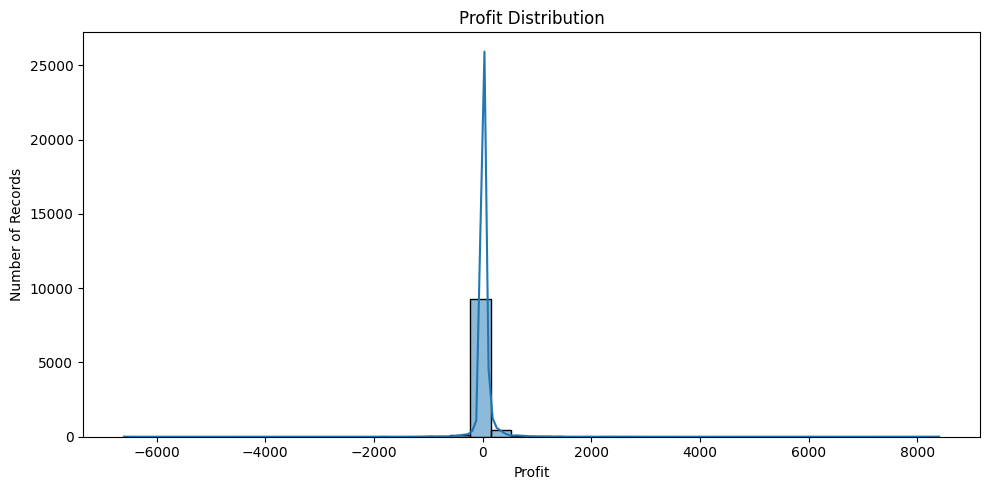

In [45]:
#  Visualization — Profit Distribution
plt.figure(figsize=(10, 5))
sns.histplot(sup["Profit"], bins=40 ,kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig('results/Visualization_11.png')
plt.show()


## Visualization: Discount vs Profit with Trend Line

### Objective

Visualize the relationship between discount levels and profit.

### Business Question

How does the discount level relate to profit?

### Interpretation

The scatter plot shows the relationship between Discount and Profit, while the trend line helps identify the overall direction of the relationship.

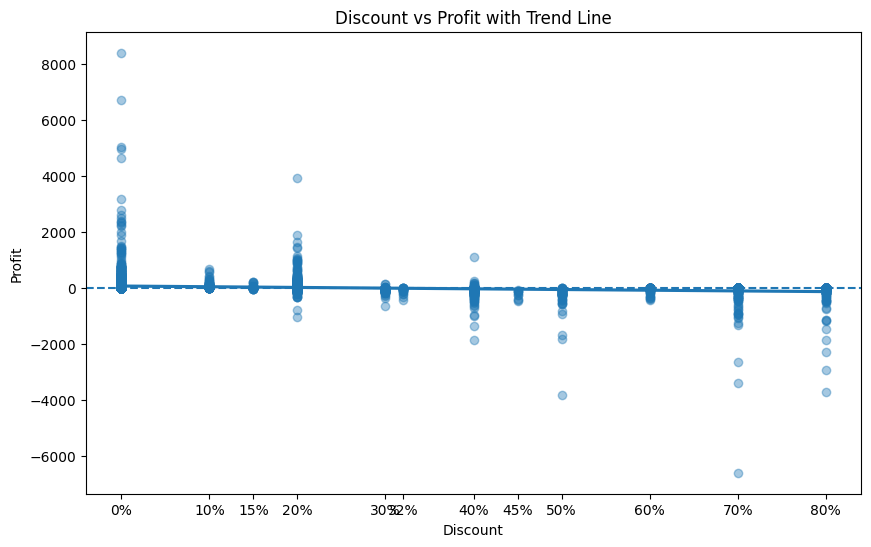

In [46]:
#  Visualization  — Discount vs Profit

plt.figure(figsize=(10, 6))

ax=sns.regplot(
    data=sup,
    x='Discount',
    y='Profit',
    scatter_kws={'alpha': 0.4},
    line_kws={}
)

# Format Discount values as percentages
ax.set_xticks(sorted(sup['Discount'].unique()))
ax.set_xticklabels(
    [f'{x:.0%}' for x in sorted(sup['Discount'].unique())]
)

plt.title('Discount vs Profit with Trend Line')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.axhline(0, linestyle='--')
plt.savefig('results/Visualization_12.png')
plt.show()

## Visualization: Sales Distribution

### Objective

Analyze the distribution of sales values across the dataset.

### Business Question

How are sales values distributed across the transactions?

### Interpretation

The distribution helps identify the common sales range and shows whether the sales data is skewed or contains extreme values.

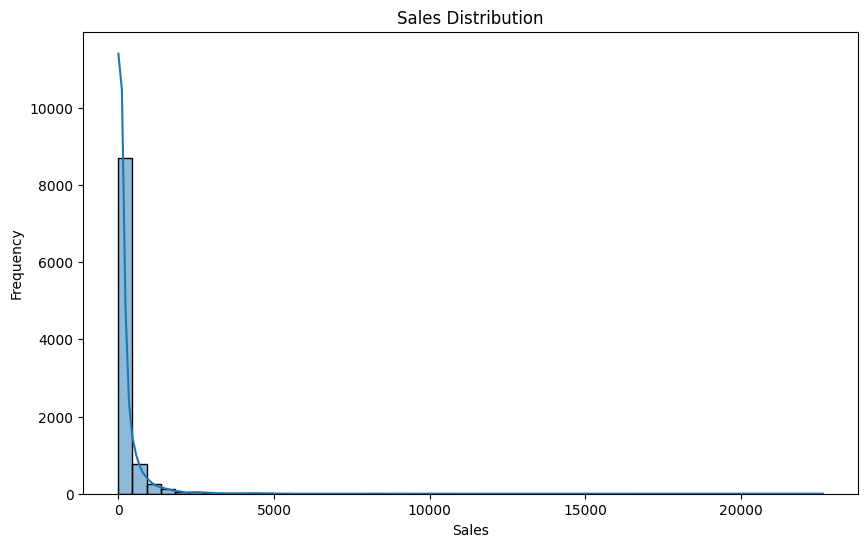

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=sup,
    x='Sales',
    bins=50,
    kde=True
)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.savefig('results/Visualization_13.png')
plt.show()

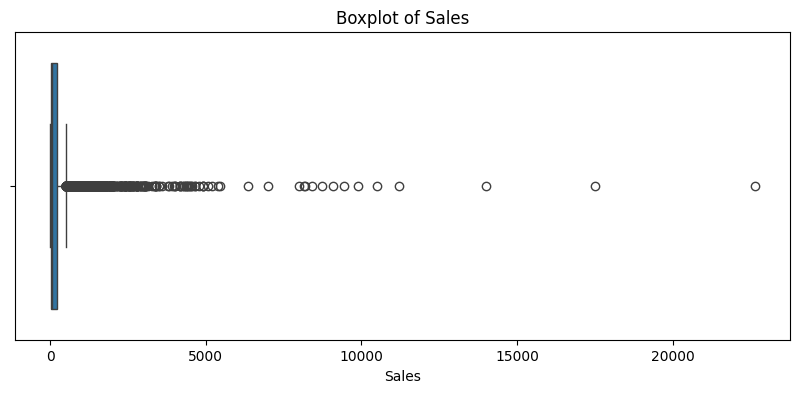

In [48]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=sup['Sales']
)

plt.title('Boxplot of Sales')
plt.xlabel('Sales')
plt.savefig('results/Visualization_14.png')
plt.show()

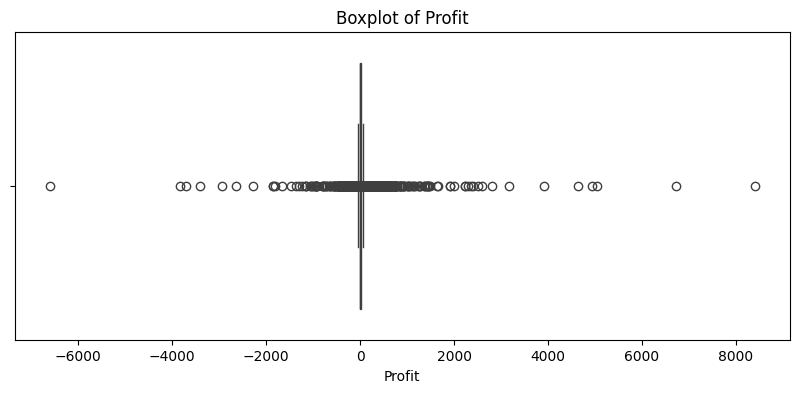

In [49]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=sup['Profit']
)

plt.title('Boxplot of Profit')
plt.xlabel('Profit')
plt.savefig('results/Visualization_15.png')
plt.show()

Sales are highly right-skewed, with most transactions having relatively low sales values and a small number of transactions generating exceptionally high sales.

# Automated Analytical Report


In [50]:
# Automated KPI Summary

total_sales = sup['Sales'].sum()
total_profit = sup['Profit'].sum()
total_orders = sup['Order ID'].nunique()
total_customers = sup['Customer ID'].nunique()
average_sales = sup['Sales'].mean()
average_profit = sup['Profit'].mean()

profit_margin = (total_profit / total_sales) * 100

print("========== KPI SUMMARY ==========")

print(f"Total Sales: {round(total_sales, 2):0.0f}")
print(f"Total Profit:{ round(total_profit, 2):0.0f}")
print(f"Profit Margin:{ round(profit_margin, 2):0.0f}" "%")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print(f"Average Sales per Record:{ round(average_sales, 2):0.0f}")
print(f"Average Profit per Record:{ round(average_profit, 2):0.0f}")

========== KPI SUMMARY ==========
Total Sales: 2297201
Total Profit:286397
Profit Margin:12%
Total Orders: 5009
Total Customers: 793
Average Sales per Record:230
Average Profit per Record:29


# Exception Handling


In [51]:
# Exception Handling

try:
    total_sales = sup['Sales'].sum()
    total_profit = sup['Profit'].sum()

    print("Total Sales:", round(total_sales, 2))
    print("Total Profit:", round(total_profit, 2))

except KeyError:
    print("Error: The required column was not found.")

except Exception as e:
    print("An unexpected error occurred:", e)


Total Sales: 2297200.86
Total Profit: 286397.02


In [52]:
# Exception Handling Example

try:
    sales = sup['Sales']
    print("Sales column found successfully.")

except KeyError:
    print("Error: Sales column does not exist.")

Sales column found successfully.


In [53]:
# Exception Handling when loading the dataset

# try:
#     sup = pd.read_excel("Superstore.xls")
#     print("Dataset loaded successfully.")

# except FileNotFoundError:
#     print("Error: The Excel file was not found.")

# except Exception as e:
#     print("An error occurred:", e)

# Performance & Memory Optimization


In [54]:
# Performance & Memory Optimization

# 1. Memory before optimization
memory_before = sup.memory_usage(deep=True).sum() / (1024 ** 2)

print("Memory before optimization:",
      round(memory_before, 2), "MB")


# 2. Convert repeated columns to category
category_columns = [
    'Ship Mode',
    'Segment',
    'Region',
    'Category',
    'Sub-Category'
]

for column in category_columns:
    sup[column] = sup[column].astype('category')


# 3. Memory after optimization
memory_after = sup.memory_usage(deep=True).sum() / (1024 ** 2)

print("Memory after optimization:",
      round(memory_after, 2), "MB")


# 4. Calculate memory reduction
memory_saved = memory_before - memory_after
percentage_saved = (memory_saved / memory_before) * 100

print("Memory saved:",
      round(memory_saved, 2), "MB")

print("Memory reduction:",
      round(percentage_saved, 2), "%")

Memory before optimization: 9.61 MB
Memory after optimization: 6.88 MB
Memory saved: 2.73 MB
Memory reduction: 28.39 %


# Export Results


In [55]:
# Export Results

import os

# Create results folder
      # os.makedirs('results', exist_ok=True)

# Export Cleaned Dataset
sup.to_csv('results/Superstore_Cleaned.csv', index=False)

# Export KPI Summary
kpi_summary.to_csv('results/KPI_Summary.csv', index=False)

# Export Category Summary
category_summary = sup.groupby('Category',observed=False)[['Sales', 'Profit']].sum()

category_summary.to_csv('results/Category_Summary.csv', index=False)

print("All data results exported successfully!")

All data results exported successfully!


In [56]:
# Download The file if you are using Google Colab

import shutil

shutil.make_archive('/content/results', 'zip', '/content/results')

print("ZIP file created successfully!")

ZIP file created successfully!


In [57]:
from google.colab import files

files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Business Insights


In [58]:
# Final Business Insights

total_sales = sup['Sales'].sum()
total_profit = sup['Profit'].sum()

profit_margin = (total_profit / total_sales) * 100

best_category = (
    sup.groupby('Category', observed=False)['Sales']
    .sum()
    .idxmax()
)

best_category_sales = (
    sup.groupby('Category', observed=False)['Sales']
    .sum()
    .max()
)

best_region = (
    sup.groupby('Region', observed=False)['Sales']
    .sum()
    .idxmax()
)

best_region_sales = (
    sup.groupby('Region', observed=False)['Sales']
    .sum()
    .max()
)

most_profitable_category = (
    sup.groupby('Category', observed=False)['Profit']
    .sum()
    .idxmax()
)

most_profitable_category_profit = (
    sup.groupby('Category', observed=False)['Profit']
    .sum()
    .max()
)

# Monthly and yearly insights
best_sales_month = monthly_performance['Sales'].idxmax()
best_sales_month_value = monthly_performance['Sales'].max()

best_sales_year = yearly_performance['Sales'].idxmax()
best_sales_year_value = yearly_performance['Sales'].max()

best_profit_month = monthly_performance['Profit'].idxmax()
best_profit_year = yearly_performance['Profit'].idxmax()


print("========== FINAL BUSINESS INSIGHTS ==========")

print(
    f"1. The company generated total sales of "
    f"${total_sales:,.2f}."
)

print(
    f"2. The company generated total profit of "
    f"${total_profit:,.2f}, with a profit margin of "
    f"{profit_margin:.2f}%."
)

print(
    f"3. The best-selling category is "
    f"{best_category}, generating "
    f"${best_category_sales:,.2f} in sales."
)

print(
    f"4. The best-performing region is "
    f"{best_region}, generating "
    f"${best_region_sales:,.2f} in sales."
)

print(
    f"5. The most profitable category is "
    f"{most_profitable_category}, generating "
    f"${most_profitable_category_profit:,.2f} in profit."
)

print(
    f"6. The month with the highest sales was "
    f"{best_sales_month}, with sales of "
    f"${best_sales_month_value:,.2f}."
)

print(
    f"7. The year with the highest sales was "
    f"{best_sales_year}, with sales of "
    f"${best_sales_year_value:,.2f}."
)

print(
    f"8. The most profitable month was "
    f"{best_profit_month}, while the most profitable year was "
    f"{best_profit_year}."
)

========== FINAL BUSINESS INSIGHTS ==========
1. The company generated total sales of $2,297,200.86.
2. The company generated total profit of $286,397.02, with a profit margin of 12.47%.
3. The best-selling category is Technology, generating $836,154.03 in sales.
4. The best-performing region is West, generating $725,457.82 in sales.
5. The most profitable category is Technology, generating $145,454.95 in profit.
6. The month with the highest sales was November, with sales of $352,461.07.
7. The year with the highest sales was 2019, with sales of $733,215.26.
8. The most profitable month was December, while the most profitable year was 2019.


# Final Conclusion

The Superstore data analysis helped us understand the company's sales and profit performance.

The company achieved total sales of approximately $2.30 million and total profit of approximately $286,397, with a profit margin of about 12.47%.

Technology was the best-performing category in terms of sales and profit, while the West region achieved the highest sales.

The analysis showed that the company should not focus only on increasing sales. Profitability and profit margin should also be monitored to make better business decisions.

The project also demonstrated how Python can be used for data cleaning, analysis, visualization, KPI calculation, and business reporting.

Overall, the analysis provides useful information that can support management in improving sales performance, profitability, and regional business strategies.

# 23. Final QA Checklist

Before considering the project complete:

- [ ] Notebook runs from top to bottom without errors.
- [ ] Dataset loading is reproducible.
- [ ] Data quality was audited before cleaning.
- [ ] Cleaning decisions are documented.
- [ ] Reusable preprocessing functions exist.
- [ ] Outliers were investigated.
- [ ] Required feature engineering is complete.
- [ ] OOP is actually used.
- [ ] Exception handling is implemented.
- [ ] Correlation analysis is complete.
- [ ] Trend analysis is complete.
- [ ] At least 8 visualizations are included.
- [ ] KPI summary is automated.
- [ ] Memory/performance was considered.
- [ ] Outputs are exported automatically.
- [ ] 8–12 business insights are written.
- [ ] Final conclusion addresses the business problem.
